In [1]:
from typing import Dict, Tuple
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import models, transforms
from torchvision.datasets import MNIST
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np

%matplotlib inline

from torch import autograd
from torch.autograd import Variable
from tensorboardX import SummaryWriter
import torch.optim as optim
import torchvision.datasets as datasets
import time
import os

if __name__ == "__main__":
    print("Torch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    print("CUDA version:", torch.version.cuda)
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.device_count() > 0 else "No GPU detected")

Torch version: 2.6.0
CUDA available: False
CUDA version: None
Number of GPUs: 0
GPU name: No GPU detected


In [2]:
import importlib
import waveguide_dataset_paired_nonorm
importlib.reload(waveguide_dataset_paired_nonorm)
from waveguide_dataset_paired_nonorm import WaveguideDatasetPaired

h5_path='train_test_split.h5'
stats_path="waveguide_stats_log_norm_above90.npz"

train_ds = WaveguideDatasetPaired(h5_path, split="train", stats_path=stats_path)
test_ds  = WaveguideDatasetPaired(h5_path, split="test",  stats_path=stats_path)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=True, num_workers=2, pin_memory=True)

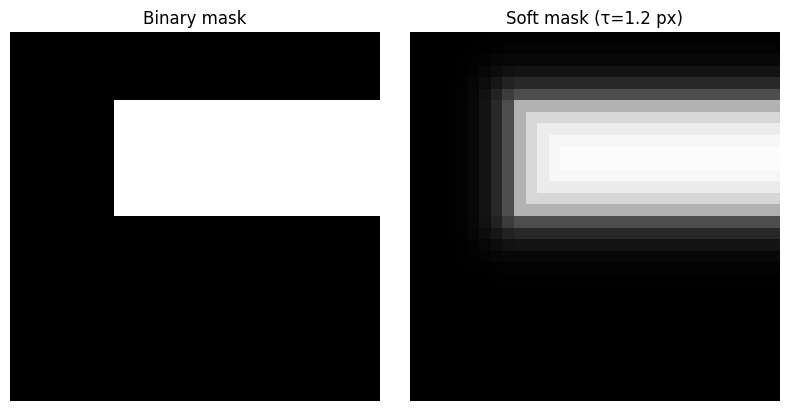

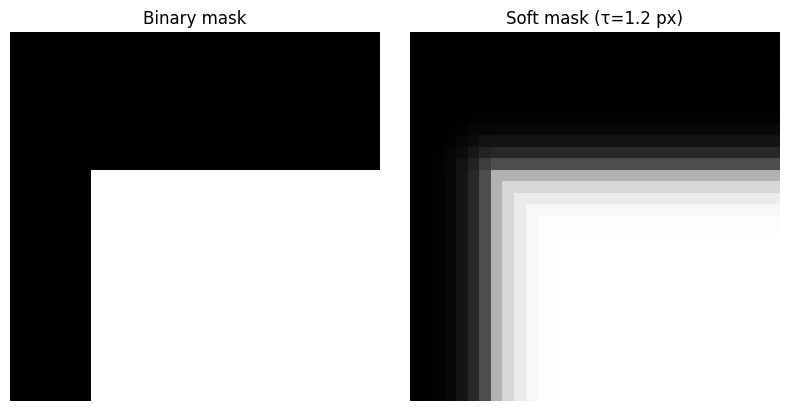

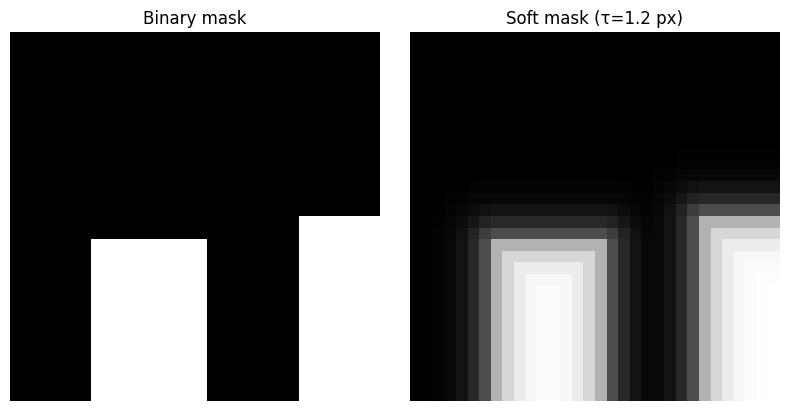

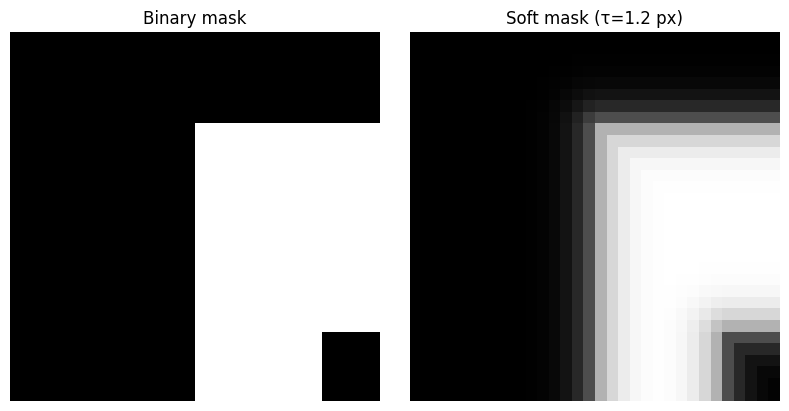

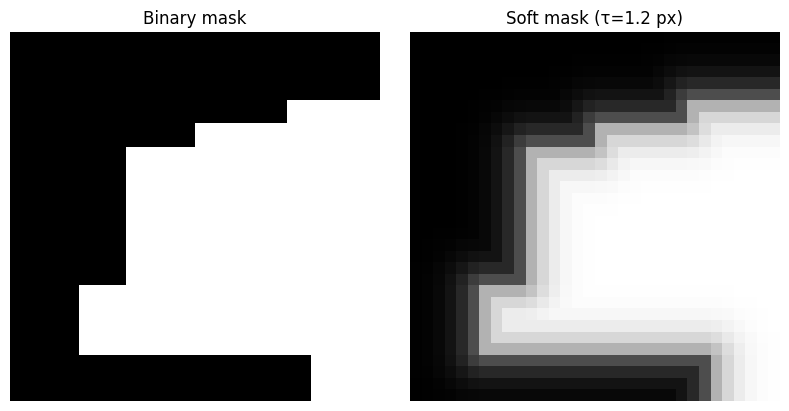

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt

def soft_mask_from_binary(bin_mask: np.ndarray, tau_pixels: float = 1.0) -> np.ndarray:
    bin_mask = (bin_mask > 0).astype(np.uint8)
    dist_in  = distance_transform_edt(bin_mask)       # inside → boundary
    dist_out = distance_transform_edt(1 - bin_mask)   # outside → boundary
    signed_dist = dist_out - dist_in                  # negative inside
    tau = max(float(tau_pixels), 1e-6)
    p_inside = 1.0 / (1.0 + np.exp(signed_dist / tau))
    return p_inside.astype(np.float32)

def _extract_waveguide_2d(wg: torch.Tensor) -> torch.Tensor:
    """
    Convert a waveguide tensor to [H, W].
    Handles [B, C, H, W], [C, H, W], [H, W, C], [H, W].
    Prefers channel 0 if multiple channels exist.
    """
    t = wg.detach().cpu()

    # If you passed a whole batch, pick the first item
    if t.ndim == 4:            # [B, C, H, W]
        t = t[0]

    if t.ndim == 3:
        # CHW?
        if t.shape[0] <= 4 and t.shape[1] == t.shape[2]:
            t = t[0]           # [H, W]
        # HWC?
        elif t.shape[2] <= 4 and t.shape[0] == t.shape[1]:
            t = t[..., 0]      # [H, W]
        else:
            t = t.squeeze()    # try to squeeze singleton channel dims

    if t.ndim != 2:
        raise ValueError(f"Could not reduce tensor to [H, W], got shape {tuple(t.shape)}")

    return t.float()

def _extract_waveguide_from_batch(batch) -> torch.Tensor:
    """
    Pull the waveguide tensor out of a typical batch like (target, params, waveguide).
    """
    if torch.is_tensor(batch):
        return batch
    if isinstance(batch, (list, tuple)):
        # Heuristic: last element is waveguide in your pipeline
        for x in reversed(batch):
            if torch.is_tensor(x):
                return x
    raise ValueError("Could not find a tensor in the batch.")

def visualize_soft_mask_from_dataloader(
    loader,
    tau_pixels: float = 1.0,
    batch_index: int = 0,
    item_index: int = 0,
    save_path: str | None = None,
):
    # Grab the batch
    for i, batch in enumerate(loader):
        if i == batch_index:
            break
    else:
        raise IndexError(f"batch_index {batch_index} beyond loader length.")

    wg_batch = _extract_waveguide_from_batch(batch)      # e.g., [B, 1, H, W] or [B, H, W]
    # Pick the item, then force to [H, W]
    wg_item = wg_batch[item_index]
    wg_2d   = _extract_waveguide_2d(wg_item)             # [H, W] float
    wg_np   = wg_2d.numpy()

    # Threshold robustly: supports [-1,1] or [0,1]
    thresh = 0.0 if wg_np.min() < 0.0 else 0.5
    bin_img = (wg_np > thresh).astype(np.uint8)

    soft_img = soft_mask_from_binary(bin_img, tau_pixels=tau_pixels)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
    axes[0].imshow(bin_img, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Binary mask"); axes[0].axis("off")

    axes[1].imshow(soft_img, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title(f"Soft mask (τ={tau_pixels:g} px)"); axes[1].axis("off")

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return {"binary": bin_img, "soft": soft_img}

# Example:
for i in range(5): 
    result = visualize_soft_mask_from_dataloader(train_loader, tau_pixels=1.2, batch_index=0, item_index=0)



In [ ]:
import h5py
import numpy as np
from scipy.ndimage import distance_transform_edt
from typing import Iterable

# ---------- Soft mask from binary (signed distance -> sigmoid) ----------
def soft_mask_from_binary(bin_mask: np.ndarray, tau_pixels: float = 1.0) -> np.ndarray:
    # bin_mask in {0,1}; returns float32 in [0,1]
    bin_mask = (bin_mask > 0).astype(np.uint8)
    dist_in  = distance_transform_edt(bin_mask)
    dist_out = distance_transform_edt(1 - bin_mask)
    signed   = dist_out - dist_in  # negative inside
    tau = max(float(tau_pixels), 1e-6)
    p_inside = 1.0 / (1.0 + np.exp(signed / tau))
    return p_inside.astype(np.float32)

# ---------- Heuristics to find waveguide datasets ----------
def name_looks_like_waveguide(name: str, keywords: Iterable[str]) -> bool:
    name_lower = name.lower()
    return any(k in name_lower for k in keywords)

def slice_is_binary_like(arr2d: np.ndarray) -> bool:
    """Returns True if arr2d looks like a binary mask."""
    if arr2d.ndim != 2:
        return False
    a = arr2d.astype(np.float32)
    mn, mx = float(a.min()), float(a.max())
    if mx == mn:
        return False
    # Handle [-1,1] or [0,1]
    if mn < 0:
        a = (a > 0).astype(np.float32)
    else:
        a = (a > 0.5).astype(np.float32)
    # Compare to original as "mostly same" after thresholding
    # If original already near 0/1, this should match closely
    diff_ratio = np.mean((arr2d.astype(np.float32) - a) != 0)
    # Also check that thresholded result is not trivial (not all 0/1)
    return diff_ratio < 0.02 and 0.01 < a.mean() < 0.99

def dataset_looks_waveguide(dset: h5py.Dataset, name: str, keywords: Iterable[str]) -> bool:
    """Decide whether to apply the transform to this dataset."""
    shape = dset.shape
    if len(shape) < 2:
        return False
    if shape[-1] != shape[-2]:
        return False  # last two dims must be square HxW

    # Quick path: name matches common waveguide keys
    if name_looks_like_waveguide(name, keywords):
        return True

    # Sample a couple slices to see if they look binary-like
    try:
        if dset.ndim == 2:
            sample = dset[...]
            return slice_is_binary_like(sample)
        elif dset.ndim == 3:
            idx = min(3, shape[0])  # sample up to 3 slices
            for i in range(idx):
                if slice_is_binary_like(dset[i, ...]):
                    return True
        elif dset.ndim == 4:
            # Assume [N, C, H, W]; sample first channel or a few
            n = min(2, shape[0])
            c = min(2, shape[1])
            for i in range(n):
                for j in range(c):
                    if slice_is_binary_like(dset[i, j, ...]):
                        return True
    except Exception:
        return False
    return False

# ---------- Apply transform, preserving shape & dtype ----------
def transform_slice_to_soft(arr2d: np.ndarray, tau: float) -> np.ndarray:
    # Robust binarization from either [0,1] or [-1,1]
    if arr2d.min() < 0:
        bin_ = (arr2d > 0).astype(np.uint8)
    else:
        bin_ = (arr2d > 0.5).astype(np.uint8)
    soft = soft_mask_from_binary(bin_, tau_pixels=tau)
    return soft

def write_preserving_filters(out_group, name, shape, dtype, src: h5py.Dataset):
    """Create destination dataset with same filters/chunking as source."""
    return out_group.create_dataset(
        name,
        shape=shape,
        dtype=dtype,
        chunks=src.chunks,
        compression=src.compression,
        compression_opts=src.compression_opts,
        shuffle=getattr(src, "shuffle", None),
        fletcher32=getattr(src, "fletcher32", False),
        scaleoffset=getattr(src, "scaleoffset", None),
    )

def copy_attrs(src_obj, dst_obj):
    for k, v in src_obj.attrs.items():
        dst_obj.attrs[k] = v

def clone_h5_with_soft_waveguides(
    src_path: str,
    dst_path: str,
    tau_pixels: float = 1.0,
    waveguide_name_keywords: Iterable[str] = ("waveguide", "wg", "pattern", "mask"),
):
    with h5py.File(src_path, "r") as fin, h5py.File(dst_path, "w") as fout:
        # Copy file-level attrs
        copy_attrs(fin, fout)

        def recurse_copy(src_grp, dst_grp, prefix=""):
            # Copy group attributes
            copy_attrs(src_grp, dst_grp)

            for name, item in src_grp.items():
                full_name = f"{prefix}/{name}" if prefix else name
                if isinstance(item, h5py.Group):
                    new_grp = dst_grp.create_group(name)
                    recurse_copy(item, new_grp, full_name)
                elif isinstance(item, h5py.Dataset):
                    dset = item
                    # Decide if we should transform
                    should_transform = dataset_looks_waveguide(dset, full_name, waveguide_name_keywords)

                    # Create destination dataset with same shape/dtype unless we transform
                    out_dtype = dset.dtype
                    if should_transform and not np.issubdtype(out_dtype, np.floating):
                        # Enforce "exactly the same" types: raise if dtype can't hold soft values
                        raise TypeError(
                            f"Dataset '{full_name}' dtype {out_dtype} is not floating; "
                            f"cannot store soft mask without changing dtype."
                        )

                    dset_out = write_preserving_filters(dst_grp, name, dset.shape, out_dtype, dset)
                    copy_attrs(dset, dset_out)

                    if not should_transform:
                        # Copy raw data as-is (efficient chunk copy)
                        dset_out[...] = dset[...]
                        continue

                    # Transform while preserving original shape (apply per 2D slice)
                    if dset.ndim == 2:
                        soft = transform_slice_to_soft(dset[...], tau_pixels)
                        dset_out[...] = soft.astype(out_dtype)
                    elif dset.ndim == 3:
                        for i in range(dset.shape[0]):
                            soft = transform_slice_to_soft(dset[i, ...], tau_pixels)
                            dset_out[i, ...] = soft.astype(out_dtype)
                    elif dset.ndim == 4:
                        # Apply per-channel if channel looks binary-like; otherwise copy that channel
                        N, C, H, W = dset.shape
                        for i in range(N):
                            for j in range(C):
                                slice2d = dset[i, j, ...]
                                if slice_is_binary_like(slice2d):
                                    soft = transform_slice_to_soft(slice2d, tau_pixels)
                                    dset_out[i, j, ...] = soft.astype(out_dtype)
                                else:
                                    dset_out[i, j, ...] = slice2d
                    else:
                        # Unexpected rank; copy as-is
                        dset_out[...] = dset[...]
                else:
                    raise RuntimeError(f"Unknown HDF5 object at {full_name}")

        recurse_copy(fin, fout)

# -------------- Example usage --------------
clone_h5_with_soft_waveguides(
    src_path="train_test_split.h5",
    dst_path="train_test_split_soft.h5",
    tau_pixels=1.2,  # edge softness in pixels
    waveguide_name_keywords=("waveguide", "wg", "pattern", "mask"),
)
